# Assessment Outline
## Classification of Voter Turnout Percent
### 2025 Gubernatorial Elections

**Three Primary Methods**
* Regression (LASSO) to find the best columns
    * serves as Feature Reduction
* Random Forest Classification
* Some kind of model interpretation: SHAP?

## Data Cleaning
### VA Census Tracts
* Import Tracts Shapfile
* Keep Only Geometry and ID Column for now

### Voting Precincts
* Identify and clean the merge column
* Keep only the merge column and geometry

### Voter Turnout
* Identify and clean the merge column
* Keep turnout and active voters
* Create turnout percent column
* Keep only merge key and turnout percent (This will be the dependent variable for the model)

### ACS

### All
* Join all Datasets Together

## Census Tracts

<Axes: >

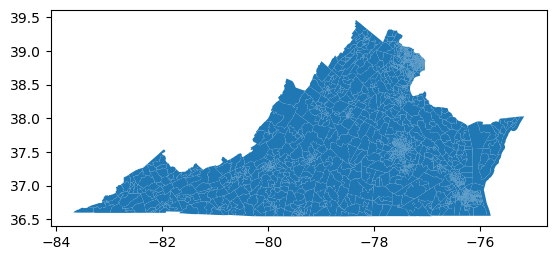

In [1]:
# Import from my github
import geopandas as gpd
url = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/census_tracts.zip"
ct = gpd.read_file(url)
ct.plot()
#ct.head(2)

In [2]:
# Keep only necessary columns: GEOID (for merging), geometry, ALAND (for population density later)
ct = ct[["GEOID", "geometry", "ALAND"]]
ct.head(2)

,GEOID,geometry,ALAND
0,51800075407,"POLYGON ((-76.63578 36.79454, -76.63557 36.794...",10334744
1,51800075105,"POLYGON ((-76.46604 36.896, -76.46057 36.90112...",6619692


## Voter Precincts

The data in this next section comes from [this github repository](https://github.com/21MetcalfJ/2024Precincts). 

The pecinct shapefile has been stored by 21MetcalfJ and collected by Twitter/X user @sz1176491. This repository contains precinct shapefiles for all 50 US states and Washington D.C. As noted in the repository, there is no uniform method of storing precinct boundary data, however several states maintain publically available shapefiles, and Virginia is one of them. This means that the shapefile of Virginia precinct stored in the repository comes from [Redistricting Data Hub](https://redistrictingdatahub.org/dataset/virginia-2024-general-election-precinct-level-results-and-boundaries/).

<Axes: >

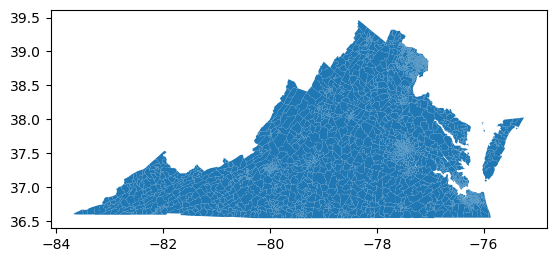

In [3]:
# Import from an external GitHub
url1 = "https://raw.githubusercontent.com/21MetcalfJ/2024Precincts/main/states/Virginia/VA24.zip"
vp = gpd.read_file(url1)
vp.plot()

In [4]:
# Keep only necessary columns: PCTKEY, geometry
vp = vp[["PCTKEY", "geometry"]].copy()
vp.head(2)

,PCTKEY,geometry
0,ARLINGTON COUNTY-112,"POLYGON ((-77.08749 38.82753, -77.08781 38.827..."
1,ARLINGTON COUNTY-128,"POLYGON ((-77.09621 38.846, -77.09626 38.84596..."


## Voter Turnout

In [5]:
# Import from my GitHub
import pandas as pd
url2 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/2025_election_turnout.csv"
vt = pd.read_csv(url2)
vt.head(2)

,election,election_date,locality,precinct,Early Voting,Election Day,Mailed Absentee,Provisional,Post-Election,TotalVoteTurnout,ActiveRegisteredVoters,InactiveRegisteredVoters,TotalRegisteredVoters
0,2025 November General,11/4/2025 0:00,ACCOMACK COUNTY,101 - CHINCOTEAGUE,275.0,1241,133.0,14.0,11.0,1674,2963,119,3082
1,2025 November General,11/4/2025 0:00,ACCOMACK COUNTY,201 - ATLANTIC,149.0,428,27.0,3.0,1.0,608,1004,41,1045


In [6]:
# Create PCTKEY Column
# Keep only the precinct number per county
vt["precinct"] = vt["precinct"].str.split(" - ").str[0]
vt["PCTKEY"] = vt["locality"] + "-" + vt["precinct"]
# Keep only necessary columns: PCTKEY, Turnoutpct
vt = vt[["PCTKEY", "TotalVoteTurnout", "ActiveRegisteredVoters"]].copy()
vt.head(2)

,PCTKEY,TotalVoteTurnout,ActiveRegisteredVoters
0,ACCOMACK COUNTY-101,1674,2963
1,ACCOMACK COUNTY-201,608,1004


## First Merge - Turnout and Precinct

* I will have to ensure that the PCT column is correct for each precinct before the merge can proceed

In [7]:
# Extract values present in one dataset and not the other
missing_vp = vp[~vp["PCTKEY"].isin(vt["PCTKEY"])]
missing_vt = vt[~vt["PCTKEY"].isin(vp["PCTKEY"])]

# Display
#missing_vp.head(2)
missing_vt.head(2)

# The main problem is that some areas store the key as BRISTOL CITY-001 in the turnout, but BRISTOL CITY-1 in the precinct

,PCTKEY,TotalVoteTurnout,ActiveRegisteredVoters
252,BRISTOL CITY-001,894,2483
253,BRISTOL CITY-002,1225,2641


#### Pad the PCTKEY column so that fits the format of "LOCALITY-00#"

In [8]:
import re

def pad_precinct_num(key):
    # Split on last hyphen
    try:
        locality, precinct = key.rsplit("-", 1)
    except ValueError:
        return key

    # Extract digits
    digits = re.findall(r"\d+", precinct)
    if not digits:
        return key

    padded = digits[0].zfill(3)
    return f"{locality}-{padded}"

vt["PCTKEY"] = vt["PCTKEY"].apply(pad_precinct_num)
vp["PCTKEY"] = vp["PCTKEY"].apply(pad_precinct_num)

missing_vp = vp[~vp["PCTKEY"].isin(vt["PCTKEY"])]
missing_vt = vt[~vt["PCTKEY"].isin(vp["PCTKEY"])]

In [9]:
print(len(missing_vp)) # was around 300 before
print(len(missing_vt)) # was around 300 before

16
12


#### Okay that solved most of the problem. Let's go back in an fix the rest

In [10]:
# Second cleaning: cut after the second hyphen in the key column
def cut_after_second_hyphen(key):
    parts = key.split("-")
    return "-".join(parts[:2])  # keep only first two parts

vt["PCTKEY"] = vt["PCTKEY"].apply(cut_after_second_hyphen)

### Still have some work to do. 
By Now I know that 4 precints in are not present in the voter record, and one has been labelled differenly.
Let's finish cleaning the merge key and rename the one that needs it

In [11]:
# Rename mismatch fairfax county precint
vt["PCTKEY"] = vt["PCTKEY"].replace({"FAIRFAX COUNTY-637": "FAIRFAX COUNTY-700"})

# Strip internal spaces in the merge keys
vt["PCTKEY"] = vt["PCTKEY"].str.strip()
vp["PCTKEY"] = vp["PCTKEY"].str.strip()

missing_vp = vp[~vp["PCTKEY"].isin(vt["PCTKEY"])]
missing_vt = vt[~vt["PCTKEY"].isin(vp["PCTKEY"])]
print(len(missing_vp))
print(len(missing_vt))

# Perfect, the four precints that aren't in the voting record will simply be removed in the merge.

4
0


#### Initiate Merge
* Locate keys present in both datasets
* Remove those that aren't
* Join the datasets on the PCTKEY column

In [12]:
# Locate the keys in both datasets
valid_keys = set(vt["PCTKEY"]).intersection(vp["PCTKEY"])
# Filter only the valid keys
vt_clean = vt[vt["PCTKEY"].isin(valid_keys)]
vp_clean = vp[vp["PCTKEY"].isin(valid_keys)]
# join the datasets
voting = vp_clean.merge(vt_clean, on="PCTKEY", how="left")
voting.head(5)

,PCTKEY,geometry,TotalVoteTurnout,ActiveRegisteredVoters
0,ARLINGTON COUNTY-112,"POLYGON ((-77.08749 38.82753, -77.08781 38.827...",1974,2693
1,ARLINGTON COUNTY-128,"POLYGON ((-77.09621 38.846, -77.09626 38.84596...",2209,3968
2,ARLINGTON COUNTY-108,"POLYGON ((-77.05425 38.86599, -77.05426 38.865...",2189,4100
3,ARLINGTON COUNTY-125,"POLYGON ((-77.10686 38.86915, -77.10964 38.868...",1913,2942
4,ARLINGTON COUNTY-124,"POLYGON ((-77.11402 38.89713, -77.11418 38.896...",2691,4134


## Census Data

In [13]:
# Read in csv files from my GitHub
url3 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/demographics.csv"
url4 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/social.csv"
url5 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/housing.csv"
url6 = "https://raw.githubusercontent.com/Ohughes-2/DSSS_Final_Assessment/main/econ.csv"

def clean_acs_csv(url):
    df = pd.read_csv(url, header=None, low_memory=False)
    # Row 1 contains the real ACS variable names
    df.columns = df.iloc[1]
    # Drop the first two rows (label row + header row)
    df = df.drop([0, 1]).reset_index(drop=True)
    return df

dem = clean_acs_csv(url3)
soc = clean_acs_csv(url4)
house = clean_acs_csv(url5)
econ = clean_acs_csv(url6)

In [14]:
dem.head(1)
#soc.head(1)
#house.head(1)
#econ.head(1)

1,Geography,Geographic Area Name,Estimate!!SEX AND AGE!!Total population,Margin of Error!!SEX AND AGE!!Total population,Estimate!!SEX AND AGE!!Total population!!Male,Margin of Error!!SEX AND AGE!!Total population!!Male,Estimate!!SEX AND AGE!!Total population!!Female,Margin of Error!!SEX AND AGE!!Total population!!Female,Estimate!!SEX AND AGE!!Total population!!Sex ratio (males per 100 females),Margin of Error!!SEX AND AGE!!Total population!!Sex ratio (males per 100 females),...,"Percent Margin of Error!!HISPANIC OR LATINO AND RACE!!Total population!!Not Hispanic or Latino!!Two or More Races!!Two races excluding Some Other Race, and three or more races",Percent!!Total housing units,Percent Margin of Error!!Total housing units,"Percent!!CITIZEN, VOTING AGE POPULATION!!Citizen, 18 and over population","Percent Margin of Error!!CITIZEN, VOTING AGE POPULATION!!Citizen, 18 and over population","Percent!!CITIZEN, VOTING AGE POPULATION!!Citizen, 18 and over population!!Male","Percent Margin of Error!!CITIZEN, VOTING AGE POPULATION!!Citizen, 18 and over population!!Male","Percent!!CITIZEN, VOTING AGE POPULATION!!Citizen, 18 and over population!!Female","Percent Margin of Error!!CITIZEN, VOTING AGE POPULATION!!Citizen, 18 and over population!!Female",NaN
0,1400000US51001090101,Census Tract 901.01; Accomack County; Virginia,1797,207,936,129,861,151,108.7,23.6,...,2.5,(X),(X),1591,(X),48.2,4.8,51.8,4.8,NaN


#### Let's Start Cleaning the Census Data

In [15]:
def clean_demographic(df):
    df.columns = df.columns.astype(str)
    # The correct ACS DP05 denominator
    total_pop_col = "Estimate!!SEX AND AGE!!Total population"
    if total_pop_col not in df.columns:
        print("Could not find:", total_pop_col)
        return df
    keep_mask = (
        df.columns.str.startswith("Percent!!") |
        (df.columns == "Geography") |
        (df.columns == total_pop_col)
    )
    df = df.loc[:, keep_mask].copy()
    # Clean names
    df.columns = [c.split("!!")[-1] if "!!" in c else c for c in df.columns]
    return df

# Force column names to be strings before running the function
dem.columns = dem.columns.astype(str)
dem = clean_demographic(dem)
dem.head(2)

,Geography,Total population,Total population,Male,Female,Sex ratio (males per 100 females),Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,...,Asian alone,Native Hawaiian and Other Pacific Islander alone,Some Other Race alone,Two or More Races,Two races including Some Other Race,"Two races excluding Some Other Race, and three or more races",Total housing units,"Citizen, 18 and over population",Male,Female
0,1400000US51001090101,1797,1797,52.1,47.9,(X),2.2,2.7,3.8,3.3,...,0.0,0.0,0.0,3.2,0.6,2.6,(X),1591,48.2,51.8
1,1400000US51001090102,1499,1499,53.0,47.0,(X),6.1,4.9,0.9,9.7,...,0.0,0.0,0.0,1.6,0.5,1.1,(X),1241,49.6,50.4


In [16]:
def clean_pct_table(df):
    # ensure column names are strings
    df.columns = df.columns.astype(str)
    # Keep Geography + percent columns
    keep_mask = (
        df.columns.str.startswith("Percent!!") |
        (df.columns == "Geography") 
    )
    df = df.loc[:, keep_mask].copy()
    # Clean names: keep only the last part after "!!"
    df.columns = [
        c.split("!!")[-1] if "!!" in c else c
        for c in df.columns
    ]
    return df

# apply function
soc = clean_pct_table(soc)
house = clean_pct_table(house)
econ = clean_pct_table(econ)

# inspect
soc.head(2)
#house.head(2)
#econ.head(2)

,Geography,Total households,Married-couple household,With children of the householder under 18 years,Cohabiting couple household,With children of the householder under 18 years,"Male householder, no spouse/partner present",With children of the householder under 18 years,Householder living alone,65 years and over,...,Slovak,Subsaharan African,Swedish,Swiss,Ukrainian,Welsh,West Indian (excluding Hispanic origin groups),Total households,With a computer,With a broadband Internet subscription
0,1400000US51001090101,945,55.3,8.0,4.6,1.4,17.2,0.0,17.2,5.6,...,0.0,0.0,1.1,0.0,0.0,0.8,0.0,945,95.2,93.4
1,1400000US51001090102,769,49.7,15.3,3.1,1.7,22.9,2.7,15.9,5.6,...,0.0,0.0,0.6,0.2,0.0,0.8,0.0,769,97.7,88.3


In [17]:
# Now I want to make a GEOID column that takes the last 11 digits of the Geography columns
# These 11 digits line up with the above census shapefile
for df in [soc, house, econ, dem]:
    df["GEOID"] = df["Geography"].astype(str).str[-11:]
    df.drop(columns=["Geography"], inplace = True)

In [18]:
# Inspect
#dem.columns
#soc.head(2)
#house.head(2)
#econ.head(2)
# Looks all good

## Second Merge: Census Tracts and Census Data

In [19]:
# This should be more simple
# Use the GEOID columns
census = (
    ct
    .merge(dem, on="GEOID", how="left")
    .merge(soc, on="GEOID", how="left")
    .merge(house, on="GEOID", how="left")
    .merge(econ, on="GEOID", how="left")
)

# Remove White space in column names
census.columns = census.columns.str.strip()

# inspect
print(len(census))
census.head(2)

2198


,GEOID,geometry,ALAND,Total population_x,Total population_x,Male,Female,Sex ratio (males per 100 females),Under 5 years,5 to 9 years,...,All people,Under 18 years,Related children of the householder under 18 years,Related children of the householder under 5 years,Related children of the householder 5 to 17 years,18 years and over_y,18 to 64 years_y,65 years and over,People in families,Unrelated individuals 15 years and over
0,51800075407,"POLYGON ((-76.63578 36.79454, -76.63557 36.794...",10334744,1451,1451,53.3,46.7,(X),3.5,5.8,...,1.5,2.7,0.0,0.0,0.0,1.4,1.1,1.8,0.0,10.3
1,51800075105,"POLYGON ((-76.46604 36.896, -76.46057 36.90112...",6619692,2608,2608,52.2,47.8,(X),2.8,10.0,...,3.1,0.0,0.0,0.0,0.0,4.0,3.9,4.5,1.2,15.2


#### Not Done Yet with the Census Data
* Remove Columns with (X) or NaN values
* Remove Duplicate Population Column

In [20]:
# remove (X) Columns
mask_any_X = census.apply(lambda col: (col == "(X)").any())
census = census.loc[:, ~mask_any_X]
# drop entirely NaN columns
census = census.dropna(axis=1, how="all")
# create a copy of the duplicate columns with a new name
census["Total_population"] = census.iloc[:, 3]
# drop the original columns
census = census.drop(census.columns[[3, 4]], axis=1)
# inspect
census.head(2)

,GEOID,geometry,ALAND,Male,Female,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,Under 18 years,Related children of the householder under 18 years,Related children of the householder under 5 years,Related children of the householder 5 to 17 years,18 years and over_y,18 to 64 years_y,65 years and over,People in families,Unrelated individuals 15 years and over,Total_population
0,51800075407,"POLYGON ((-76.63578 36.79454, -76.63557 36.794...",10334744,53.3,46.7,3.5,5.8,4.7,3.0,4.0,...,2.7,0.0,0.0,0.0,1.4,1.1,1.8,0.0,10.3,1451
1,51800075105,"POLYGON ((-76.46604 36.896, -76.46057 36.90112...",6619692,52.2,47.8,2.8,10.0,6.9,5.0,4.5,...,0.0,0.0,0.0,0.0,4.0,3.9,4.5,1.2,15.2,2608


In [21]:
# Remove any other duplicates
census = census.loc[:, ~census.columns.duplicated()]
# Let's make values numeric: except geometry and GEOID code
cols = census.columns.difference(["GEOID", "geometry"])
census[cols] = census[cols].apply(pd.to_numeric, errors="coerce")
# Now let's make a population density column
# People per Km^2
# Replace 0 ALAND with a small number close to 0
census["ALAND"] = census["ALAND"].replace(0, 1e-6)
census["Popden_Km"] = round((census["Total_population"]) / (census["ALAND"] / 1000000),3)
census.head(2)

/opt/conda/lib/python3.12/site-packages/geopandas/geodataframe.py:1968: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


,GEOID,geometry,ALAND,Male,Female,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,Related children of the householder under 18 years,Related children of the householder under 5 years,Related children of the householder 5 to 17 years,18 years and over_y,18 to 64 years_y,65 years and over,People in families,Unrelated individuals 15 years and over,Total_population,Popden_Km
0,51800075407,"POLYGON ((-76.63578 36.79454, -76.63557 36.794...",10334744.0,53.3,46.7,3.5,5.8,4.7,3.0,4.0,...,0.0,0.0,0.0,1.4,1.1,1.8,0.0,10.3,1451,140.400
1,51800075105,"POLYGON ((-76.46604 36.896, -76.46057 36.90112...",6619692.0,52.2,47.8,2.8,10.0,6.9,5.0,4.5,...,0.0,0.0,0.0,4.0,3.9,4.5,1.2,15.2,2608,393.976


In [22]:
# Make a new copy to maintain computation speed
census = census.copy()
census.tail(2)

,GEOID,geometry,ALAND,Male,Female,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,Related children of the householder under 18 years,Related children of the householder under 5 years,Related children of the householder 5 to 17 years,18 years and over_y,18 to 64 years_y,65 years and over,People in families,Unrelated individuals 15 years and over,Total_population,Popden_Km
2196,51660000301,"POLYGON ((-78.91491 38.43829, -78.91376 38.440...",5635773.0,49.8,50.2,6.7,3.6,6.8,5.3,0.8,...,0.0,0.0,0.0,2.5,1.7,4.4,0.0,9.5,3295,584.658
2197,51187020400,"POLYGON ((-78.22035 38.93329, -78.22017 38.934...",6385735.0,50.0,50.0,7.7,5.9,6.7,2.7,5.3,...,13.4,11.2,14.8,10.4,8.9,15.2,8.0,18.0,5207,815.411


## Join the Census Tracts and Vote Data.
They do not follow the same geography
* If 90% of a precinct falls within a tract, that tract gets 90% of the voter turnout and 90% of the active registered voters
* The main limitation of this is that is assumes population is distributed evenly within voting precincts

In [23]:
# Ensure the data is in the same crs
voting = voting.to_crs(3968) # Virginia North Region - Meters
census = census.to_crs(3968)

In [24]:
# Compute precinct areas
voting["precinct_area"] = voting.geometry.area
# intersect the two shapefiles
intersections = gpd.overlay(voting, census, how="intersection")
# area of each intersection
intersections["intersect_area"] = intersections.geometry.area
# how much of each precinct falls within each tract
intersections["pct_of_precinct"] = (intersections["intersect_area"] / intersections["precinct_area"])
# allotcate the voting data propotionally 
intersections["allocated_turnout"] = (intersections["TotalVoteTurnout"] * intersections["pct_of_precinct"])
intersections["allocated_registered"] = (intersections["ActiveRegisteredVoters"] * intersections["pct_of_precinct"])
# aggregate back to the tract level
tract_vote = (
    intersections.groupby("GEOID")[["allocated_turnout", "allocated_registered"]]
    .sum()
    .reset_index()
)
# join back to the census data
data = census.merge(tract_vote, on="GEOID", how="left")
# inspect
data.head(2)

,GEOID,geometry,ALAND,Male,Female,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,Related children of the householder 5 to 17 years,18 years and over_y,18 to 64 years_y,65 years and over,People in families,Unrelated individuals 15 years and over,Total_population,Popden_Km,allocated_turnout,allocated_registered
0,51800075407,"POLYGON ((255613.762 92148.798, 255631.549 921...",10334744.0,53.3,46.7,3.5,5.8,4.7,3.0,4.0,...,0.0,1.4,1.1,1.8,0.0,10.3,1451,140.400,1547.008871,2686.956644
1,51800075105,"POLYGON ((270387.972 103886.14, 270856.804 104...",6619692.0,52.2,47.8,2.8,10.0,6.9,5.0,4.5,...,0.0,4.0,3.9,4.5,1.2,15.2,2608,393.976,2042.416678,3256.307323


In [25]:
# Create the voter turnout percent that will become the dependent variable of the model.
data["Turnoutpct"] = round((data["allocated_turnout"] / data["allocated_registered"]) * 100,3)
data.head(2)

,GEOID,geometry,ALAND,Male,Female,Under 5 years,5 to 9 years,10 to 14 years,15 to 19 years,20 to 24 years,...,18 years and over_y,18 to 64 years_y,65 years and over,People in families,Unrelated individuals 15 years and over,Total_population,Popden_Km,allocated_turnout,allocated_registered,Turnoutpct
0,51800075407,"POLYGON ((255613.762 92148.798, 255631.549 921...",10334744.0,53.3,46.7,3.5,5.8,4.7,3.0,4.0,...,1.4,1.1,1.8,0.0,10.3,1451,140.400,1547.008871,2686.956644,57.575
1,51800075105,"POLYGON ((270387.972 103886.14, 270856.804 104...",6619692.0,52.2,47.8,2.8,10.0,6.9,5.0,4.5,...,4.0,3.9,4.5,1.2,15.2,2608,393.976,2042.416678,3256.307323,62.722


## Quick Chloropleth Map of the turnout pct

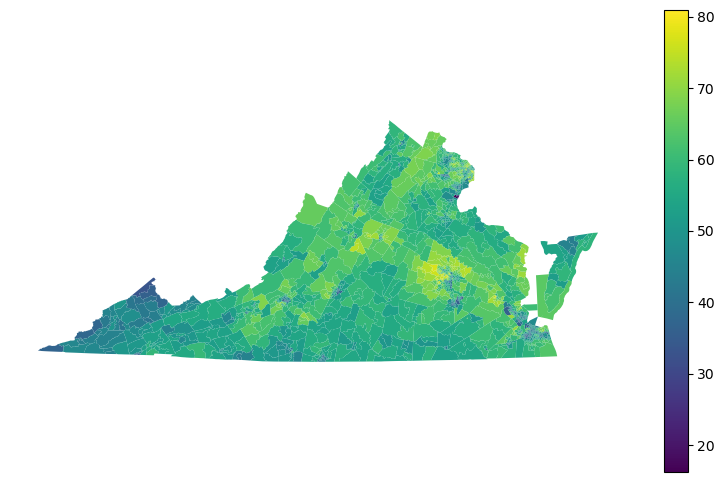

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 8))

data.plot(
    column="Turnoutpct",
    cmap="viridis",
    linewidth=0,
    legend=True,
    legend_kwds={"shrink": 0.6},  # keeps it small
    ax=ax
)

ax.set_axis_off()
plt.tight_layout()
plt.show()


## Export the new shape file

In [29]:
#data.to_file("complete_data.shp")

In [32]:
votes_per_tract = data.copy()
# Convert geometry to WKT
votes_per_tract["geometry"] = votes_per_tract["geometry"].to_wkt()
# Export to CSV
votes_per_tract.to_csv("votes_per_tract.csv", index=False)

/tmp/ipykernel_720/4234614994.py:3: UserWarning: Geometry column does not contain geometry.
  votes_per_tract["geometry"] = votes_per_tract["geometry"].to_wkt()
